# Bodrum Hotel & Destination Intelligence
## Google Travel x Sikayetvar Cross-Source Customer Voice Alignment

Google Travel is a general guest review corpus (any sentiment); Sikayetvar is a complaint-focused,
self-selected corpus (only unhappy guests post). This notebook compares them at the hotel_id /
canonical-aspect summary level only - never row-level - and never as one sentiment distribution.
Google Travel was **not** re-scraped for this task; Sikayetvar was not re-scraped beyond the
targeted verified-page collection already reflected in the v3 clean dataset.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / 'reports').exists(): ROOT = ROOT.parent
R = ROOT / 'reports'

coverage = pd.read_csv(R / 'google_sikayetvar_cross_source_coverage.csv')
hotel_alignment = pd.read_csv(R / 'google_sikayetvar_hotel_alignment.csv')
aspect_alignment = pd.read_csv(R / 'google_sikayetvar_aspect_alignment.csv')
divergence = pd.read_csv(R / 'google_sikayetvar_source_divergence.csv')
key_findings = pd.read_csv(R / 'google_sikayetvar_key_findings.csv')
crosswalk = pd.read_csv(ROOT / 'config' / 'google_sikayetvar_aspect_crosswalk.csv')
print('Loaded:', len(hotel_alignment), 'common hotels |', len(aspect_alignment), 'hotel-aspect rows')

Loaded: 38 common hotels | 798 hotel-aspect rows


## 1. Coverage

,hotel_set,hotel_count
0,google_covered,104
1,sikayetvar_verified,62
2,complaint_bearing,44
3,page_no_complaint,15
4,common_verified,38
5,common_complaint_bearing,27
6,common_page_no_complaint,9
7,supported_common,15


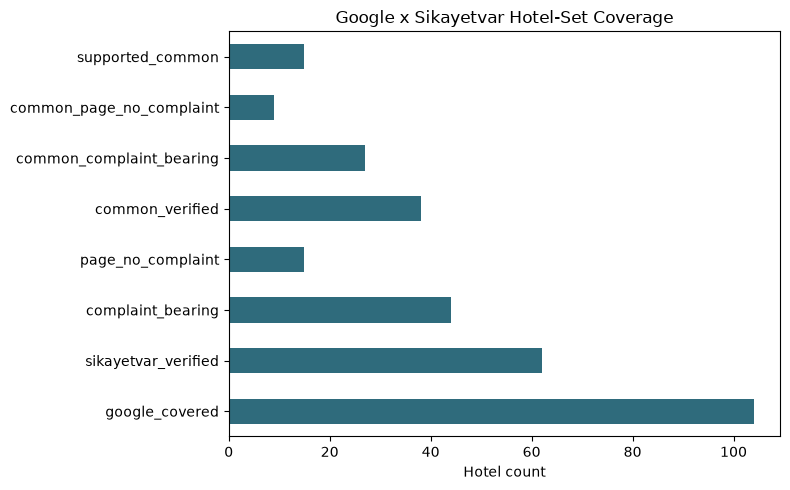

In [2]:
display(coverage)
ax = coverage.set_index('hotel_set')['hotel_count'].plot.barh(figsize=(8,5), color='#2F6B7C')
ax.set_xlabel('Hotel count'); ax.set_ylabel(''); ax.set_title('Google x Sikayetvar Hotel-Set Coverage')
plt.tight_layout(); plt.show()

## 2. Aspect Crosswalk

In [3]:
display(crosswalk)

,canonical_aspect,google_aspects,sikayetvar_aspects,note
0,STAFF_SERVICE,STAFF|SERVICE,STAFF_SERVICE,Direct conceptual match; Google splits STAFF (...
1,MANAGEMENT_COMMUNICATION,MANAGEMENT|COMMUNICATION,MANAGEMENT_COMMUNICATION,Hotel-management responsiveness and guest-mana...
2,CLEANLINESS_HYGIENE,CLEANLINESS|HYGIENE,CLEANLINESS_HYGIENE,Direct match; Google splits general cleanlines...
3,FOOD_BEVERAGE,FOOD|BAR_DRINKS,FOOD_BEVERAGE,Google separates food and bar/drinks; Sikayetv...
4,ROOM_COMFORT,ROOM|BED_COMFORT,ROOM,Google's BED_COMFORT is a sub-signal of the sa...
5,FACILITIES_MAINTENANCE,FACILITIES,FACILITIES_MAINTENANCE,Direct conceptual match (general hotel facilit...
6,POOL,POOL,POOL,Direct exact match; kept as its own canonical ...
7,BEACH_SEA,BEACH_SEA,BEACH_SEA,Direct exact match.
8,PRICE_VALUE,PRICE_VALUE,PRICE_VALUE,Direct exact match.
9,RESERVATION,RESERVATION,RESERVATION,Direct exact match.


## 3. Aspect Alignment Label Distribution
Multi-label rule-based signals, not a model output.

alignment_label
NO_SIGNAL                       268
GOOGLE_GENERAL_ONLY             228
LOW_SUPPORT                     192
BOTH_SOURCE_CONCERN              48
GOOGLE_STRENGTH_VS_COMPLAINT     33
SIKAYETVAR_ONLY                  29
Name: count, dtype: int64

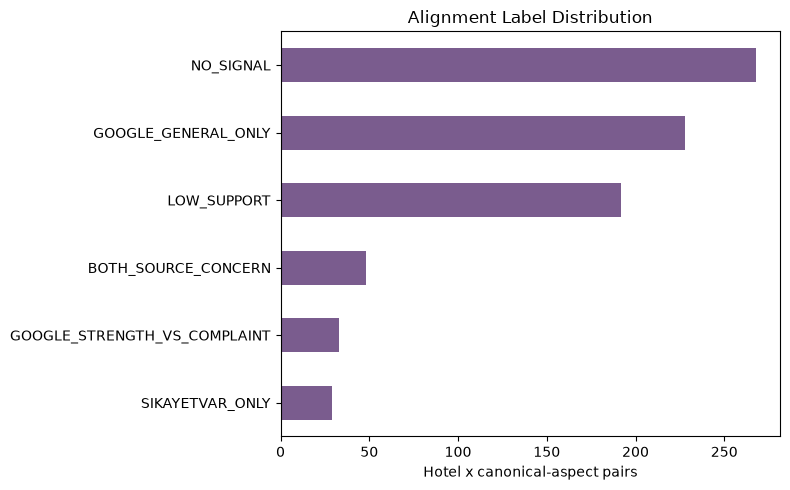

In [4]:
label_counts = aspect_alignment['alignment_label'].value_counts()
display(label_counts)
ax = label_counts.sort_values().plot.barh(figsize=(8,5), color='#7A5C8E')
ax.set_xlabel('Hotel x canonical-aspect pairs'); ax.set_ylabel(''); ax.set_title('Alignment Label Distribution')
plt.tight_layout(); plt.show()

## 4. Aspect Alignment Heatmap (supported hotels)

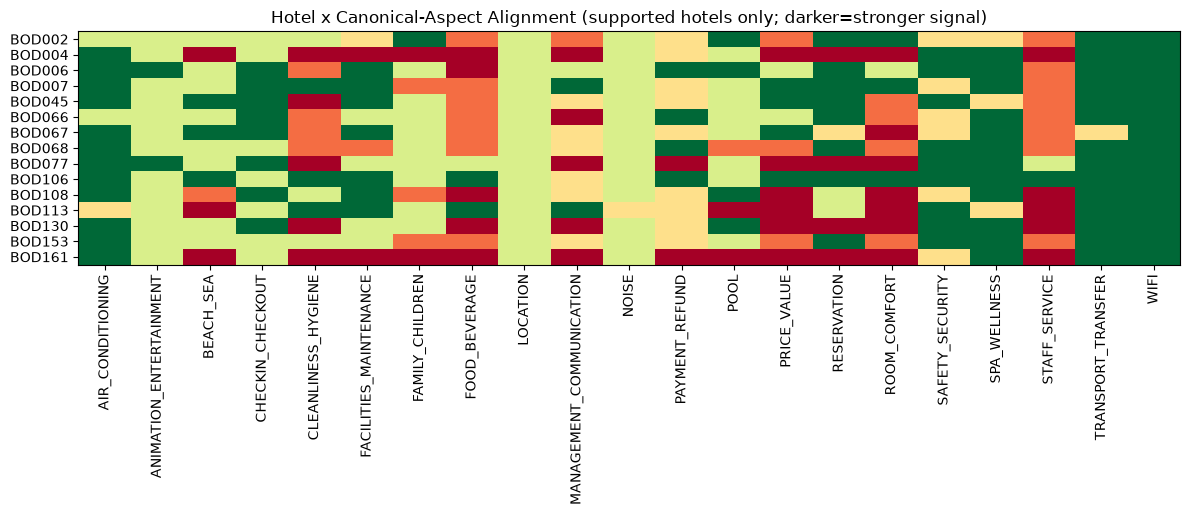

In [5]:
supported_ids = hotel_alignment.loc[hotel_alignment['hotel_is_supported_common'], 'hotel_id']
pivot_source = aspect_alignment.loc[aspect_alignment['hotel_id'].isin(supported_ids)]
label_rank = {'NO_SIGNAL':0,'LOW_SUPPORT':1,'GOOGLE_GENERAL_ONLY':2,'SIKAYETVAR_ONLY':3,'GOOGLE_STRENGTH_VS_COMPLAINT':4,'BOTH_SOURCE_CONCERN':5}
pivot_source = pivot_source.assign(label_rank=pivot_source['alignment_label'].map(label_rank))
pivot = pivot_source.pivot_table(index='hotel_id', columns='canonical_aspect', values='label_rank', aggfunc='max')
if not pivot.empty:
    fig, ax = plt.subplots(figsize=(12, max(4, 0.35*len(pivot))))
    im = ax.imshow(pivot.fillna(-1).values, cmap='RdYlGn_r', aspect='auto')
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=90)
    ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
    ax.set_title('Hotel x Canonical-Aspect Alignment (supported hotels only; darker=stronger signal)')
    plt.tight_layout(); plt.show()
else:
    print('No supported hotels at current thresholds.')

## 5. Hotel-Level Alignment Table

In [6]:
display(hotel_alignment.loc[hotel_alignment['hotel_is_supported_common']].sort_values('sikayetvar_complaint_n', ascending=False))

,hotel_id,hotel_name,area,google_review_n,google_mean_rating,google_low_share,google_high_share,google_sample_support,sikayetvar_complaint_n,sikayetvar_page_status,sikayetvar_top_aspects,sikayetvar_company_reply_visibility_pct,complaint_visibility_per_1000_google_reviews,visibility_support_flag,hotel_is_supported_common
0,BOD007,Kefaluka Resort,Akyarlar,60,4.066667,0.183,0.733,STRONGER,29,VISIBLE_COMPLAINTS,STAFF_SERVICE:65.5%|MANAGEMENT_COMMUNICATION:6...,75.862069,6.755183,STRONGER_DENOMINATOR,True
1,BOD161,MyElla Hotel Resort & Spa,Turgutreis,10,1.500000,0.900,0.000,LOW_SUPPORT,28,VISIBLE_COMPLAINTS,STAFF_SERVICE:78.6%|CLEANLINESS_HYGIENE:64.3%|...,0.000000,9.569378,STRONGER_DENOMINATOR,True
2,BOD106,La Blanche Island Bodrum,Güvercinlik,11,3.727273,0.091,0.545,LOW_SUPPORT,19,VISIBLE_COMPLAINTS,STAFF_SERVICE:73.7%|ROOM:68.4%|BEACH_SEA:47.4%,26.315789,2.881407,STRONGER_DENOMINATOR,True
3,BOD066,Royal Asarlik Beach Hotel & Spa,Gümbet,10,4.020000,0.100,0.700,LOW_SUPPORT,18,VISIBLE_COMPLAINTS,RESERVATION:66.7%|STAFF_SERVICE:61.1%|MANAGEME...,0.000000,5.126745,STRONGER_DENOMINATOR,True
4,BOD108,Lujo Hotel Bodrum,Güvercinlik,10,3.600000,0.400,0.600,LOW_SUPPORT,15,VISIBLE_COMPLAINTS,STAFF_SERVICE:66.7%|PRICE_VALUE:46.7%|FAMILY_C...,0.000000,4.703669,STRONGER_DENOMINATOR,True
5,BOD130,Petunya Beach Resort,Ortakent-Yahşi,10,3.300000,0.400,0.600,LOW_SUPPORT,13,VISIBLE_COMPLAINTS,MANAGEMENT_COMMUNICATION:84.6%|PAYMENT_REFUND:...,0.000000,4.838109,STRONGER_DENOMINATOR,True
6,BOD004,Bendis Beach Hotel,Akyarlar,10,2.000000,0.700,0.300,LOW_SUPPORT,12,VISIBLE_COMPLAINTS,FOOD_BEVERAGE:75.0%|ROOM:75.0%|CLEANLINESS_HYG...,41.666667,4.860267,STRONGER_DENOMINATOR,True
7,BOD153,The Oba Hotel,Torba,10,4.600000,0.000,0.900,LOW_SUPPORT,10,VISIBLE_COMPLAINTS,PAYMENT_REFUND:80.0%|PRICE_VALUE:60.0%|ROOM:60.0%,0.000000,16.583748,LOW_DENOMINATOR,True
8,BOD068,Selectum Colours Bodrum,Gümbet,10,3.900000,0.200,0.700,LOW_SUPPORT,9,VISIBLE_COMPLAINTS,ROOM:88.9%|MANAGEMENT_COMMUNICATION:77.8%|STAF...,0.000000,0.671041,STRONGER_DENOMINATOR,True
9,BOD002,Armonia Holiday Village & Spa,Akyarlar,10,3.600000,0.200,0.600,LOW_SUPPORT,8,VISIBLE_COMPLAINTS,FOOD_BEVERAGE:75.0%|ROOM:75.0%|SAFETY_SECURITY...,0.000000,2.502346,STRONGER_DENOMINATOR,True


## 6. Google Low-Context Share vs Sikayetvar Complaint Mention Rate

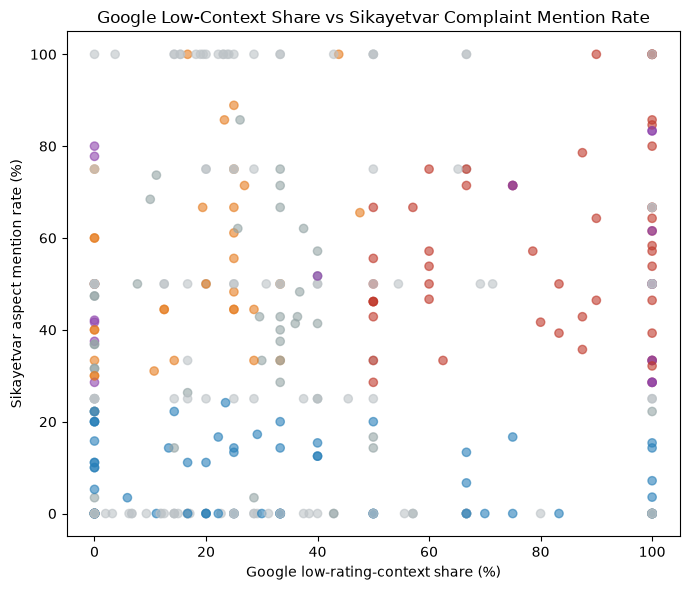

In [7]:
scatter_df = aspect_alignment.dropna(subset=['google_low_context_share','sikayetvar_mention_rate_pct'])
fig, ax = plt.subplots(figsize=(7,6))
colors = scatter_df['alignment_label'].map({'BOTH_SOURCE_CONCERN':'#C0392B','GOOGLE_STRENGTH_VS_COMPLAINT':'#E67E22','SIKAYETVAR_ONLY':'#8E44AD','GOOGLE_GENERAL_ONLY':'#2980B9','LOW_SUPPORT':'#BDC3C7','NO_SIGNAL':'#95A5A6'})
ax.scatter(scatter_df['google_low_context_share'], scatter_df['sikayetvar_mention_rate_pct'], c=colors, alpha=0.6)
ax.set_xlabel('Google low-rating-context share (%)'); ax.set_ylabel('Sikayetvar aspect mention rate (%)')
ax.set_title('Google Low-Context Share vs Sikayetvar Complaint Mention Rate')
plt.tight_layout(); plt.show()

## 7. Complaint Visibility Indicator vs Google Rating Profile
Not a real complaint rate - see limitations.

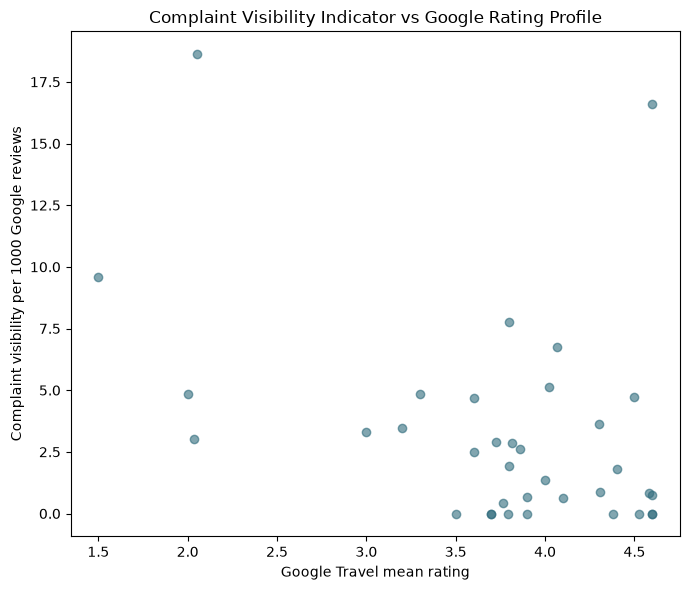

In [8]:
vis_df = hotel_alignment.dropna(subset=['complaint_visibility_per_1000_google_reviews'])
fig, ax = plt.subplots(figsize=(7,6))
ax.scatter(vis_df['google_mean_rating'], vis_df['complaint_visibility_per_1000_google_reviews'], alpha=0.6, color='#2F6B7C')
ax.set_xlabel('Google Travel mean rating'); ax.set_ylabel('Complaint visibility per 1000 Google reviews')
ax.set_title('Complaint Visibility Indicator vs Google Rating Profile')
plt.tight_layout(); plt.show()

## 8. Selected Divergence Examples
Descriptive only - no hotel ranking.

In [9]:
display(divergence.head(20))

,hotel_id,canonical_aspect,google_mention_rate_pct,google_support_n,google_low_context_share,google_high_context_share,sikayetvar_mention_rate_pct,sikayetvar_hotel_n,sikayetvar_small_n_flag,alignment_label,hotel_name,area
0,BOD077,MANAGEMENT_COMMUNICATION,30.0,20,100.0,0.0,100.000000,7,False,BOTH_SOURCE_CONCERN,Ladonia Hotels Zemda,Gümüşlük
1,BOD077,PRICE_VALUE,50.0,20,90.0,10.0,100.000000,7,False,BOTH_SOURCE_CONCERN,Ladonia Hotels Zemda,Gümüşlük
2,BOD077,RESERVATION,25.0,20,100.0,0.0,100.000000,7,False,BOTH_SOURCE_CONCERN,Ladonia Hotels Zemda,Gümüşlük
3,BOD077,PAYMENT_REFUND,20.0,20,100.0,0.0,100.000000,7,False,BOTH_SOURCE_CONCERN,Ladonia Hotels Zemda,Gümüşlük
4,BOD113,ROOM_COMFORT,63.6,11,100.0,57.1,85.714286,7,False,BOTH_SOURCE_CONCERN,Kadıkale Resort,Kadıkalesi
5,BOD130,MANAGEMENT_COMMUNICATION,20.0,10,100.0,100.0,84.615385,13,False,BOTH_SOURCE_CONCERN,Petunya Beach Resort,Ortakent-Yahşi
6,BOD006,FOOD_BEVERAGE,70.0,10,100.0,85.7,80.000000,5,False,BOTH_SOURCE_CONCERN,Club Marma Hotel,Akyarlar
7,BOD161,STAFF_SERVICE,80.0,10,87.5,0.0,78.571429,28,False,BOTH_SOURCE_CONCERN,MyElla Hotel Resort & Spa,Turgutreis
8,BOD004,FOOD_BEVERAGE,60.0,10,60.0,50.0,75.000000,12,False,BOTH_SOURCE_CONCERN,Bendis Beach Hotel,Akyarlar
9,BOD004,ROOM_COMFORT,90.0,10,66.7,50.0,75.000000,12,False,BOTH_SOURCE_CONCERN,Bendis Beach Hotel,Akyarlar


## 9. Key Findings

In [10]:
display(key_findings)

,finding_id,level,hotel_id,hotel_name,finding,evidence_metric,evidence_value,support_n,confidence,limitation
0,GSF001,GLOBAL,NaN,NaN,27 hotels have both Google Travel review data ...,common_complaint_bearing_hotel_n,27.0,27,HIGH,Google and Sikayetvar are different population...
1,GSF002,GLOBAL,NaN,NaN,15 hotels have enough sample size on both side...,supported_common_hotel_n,15.0,15,HIGH,Comparisons outside this supported set should ...
2,GSF003,HOTEL,BOD077,Ladonia Hotels Zemda,MANAGEMENT_COMMUNICATION shows up as a concern...,sikayetvar_mention_rate_pct,100.0,7,MEDIUM,Two independently-biased corpora agreeing incr...
3,GSF004,HOTEL,BOD077,Ladonia Hotels Zemda,PRICE_VALUE shows up as a concern in BOTH Goog...,sikayetvar_mention_rate_pct,100.0,7,MEDIUM,Two independently-biased corpora agreeing incr...
4,GSF005,HOTEL,BOD077,Ladonia Hotels Zemda,PAYMENT_REFUND shows up as a concern in BOTH G...,sikayetvar_mention_rate_pct,100.0,7,MEDIUM,Two independently-biased corpora agreeing incr...
5,GSF006,HOTEL,BOD077,Ladonia Hotels Zemda,RESERVATION shows up as a concern in BOTH Goog...,sikayetvar_mention_rate_pct,100.0,7,MEDIUM,Two independently-biased corpora agreeing incr...
6,GSF007,HOTEL,BOD113,Kadıkale Resort,ROOM_COMFORT shows up as a concern in BOTH Goo...,sikayetvar_mention_rate_pct,85.7,7,MEDIUM,Two independently-biased corpora agreeing incr...
7,GSF008,HOTEL,BOD130,Petunya Beach Resort,MANAGEMENT_COMMUNICATION shows up as a concern...,sikayetvar_mention_rate_pct,84.6,13,MEDIUM,Two independently-biased corpora agreeing incr...
8,GSF009,HOTEL,BOD006,Club Marma Hotel,FOOD_BEVERAGE shows up as a concern in BOTH Go...,sikayetvar_mention_rate_pct,80.0,5,MEDIUM,Two independently-biased corpora agreeing incr...
9,GSF010,HOTEL,BOD161,MyElla Hotel Resort & Spa,STAFF_SERVICE shows up as a concern in BOTH Go...,sikayetvar_mention_rate_pct,78.6,28,MEDIUM,Two independently-biased corpora agreeing incr...


## 10. Limitations

- Google Travel (general reviews) and Sikayetvar (complaints) are different, differently-biased populations;
  they are never compared as one sentiment distribution.
- No row-level merge; all comparison is at hotel_id / canonical-aspect summary level.
- The aspect crosswalk required judgment calls and is not the only valid mapping (see config file).
- Support thresholds are deliberately conservative (precision over coverage); many hotel-aspect pairs are LOW_SUPPORT.
- complaint_visibility_per_1000_google_reviews is a visibility indicator, not a real complaint rate.
- No 'best'/'worst' hotel ranking is produced anywhere in this notebook.

In [11]:
assert hotel_alignment['hotel_id'].is_unique
assert set(aspect_alignment['alignment_label']).issubset({
    'BOTH_SOURCE_CONCERN','GOOGLE_GENERAL_ONLY','SIKAYETVAR_ONLY','GOOGLE_STRENGTH_VS_COMPLAINT','NO_SIGNAL','LOW_SUPPORT'
})
assert not aspect_alignment.duplicated(['hotel_id','canonical_aspect']).any()
print('FINAL NOTEBOOK VALIDATION: PASS')

FINAL NOTEBOOK VALIDATION: PASS
